# Análisis de coherencia de outliers (CRIM, ZN, B)

La regla de IQR sola marca demasiados "outliers" en variables muy asimétricas (CRIM, ZN, B) que en realidad son la cola larga de una distribución real, no errores. Este análisis agrega un segundo filtro: para cada outlier, chequea si su relación con el target (MEDV) y con otras variables correlacionadas por dominio va en la dirección que el propio EDA (matriz de correlación) predice.

**Corrección importante**: la fracción de relaciones rotas se calcula sobre las relaciones que efectivamente se pudieron *evaluar* (ignorando NaN), no sobre un conteo absoluto. Así, una fila con una sola relación evaluable que la rompe pesa tanto como una con tres relaciones evaluables que rompe las tres — antes, una fila con datos faltantes en las variables secundarias quedaba injustamente protegida de ser marcada como incoherente.

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Datos

Igual que en el resto del pipeline: nunca se imputa MEDV, se dropean sus nulos primero, antes de analizar cualquier otra cosa.

In [10]:
df = pd.read_csv('house-prices-tp.csv')
df_limpio = df.dropna(subset=['MEDV']).copy()

## Función: detectar outliers por IQR

Marca los outliers de una columna con la regla clásica (Q1 - 1.5·IQR, Q3 + 1.5·IQR) y guarda de qué lado cae cada uno ('alto' o 'bajo'), que se usa después para juzgar coherencia.

In [11]:
def detectar_outliers_iqr(df, columna):
    serie = df[columna].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    df_outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)].copy()
    df_outliers['lado'] = np.where(df_outliers[columna] > lim_sup, 'alto', 'bajo')
    return df_outliers, lim_inf, lim_sup

## Función: chequear coherencia

Para los outliers de una columna, evalúa si el valor extremo es coherente con la relación esperada respecto al target y a otras variables correlacionadas por dominio (según la matriz de correlación del EDA).

- `direccion`: +1 si la columna correlaciona POSITIVO con el target, -1 si correlaciona NEGATIVO (esto sale de la matriz de correlación, no es un supuesto arbitrario).
- `relaciones`: dict opcional `{nombre_var: signo_esperado}` con otras variables relacionadas por dominio (ej: `{'LSTAT': 1, 'RM': -1}` para CRIM).
- `umbral_fraccion`: proporción mínima de relaciones **evaluables** que se deben romper para marcar la fila como incoherente (0.5 = rompe la mayoría, 1.0 = rompe absolutamente todo lo que se pudo chequear).

Cada outlier se compara contra la **mediana global** de cada variable (no la mediana de los outliers). Las filas con NaN en la variable comparada no cuentan ni a favor ni en contra: simplemente reducen el denominador de la fracción, en vez de bajar el conteo absoluto como en una primera versión de este análisis (que subestimaba la incoherencia de filas con más datos faltantes).

In [12]:
def chequear_coherencia(df, columna, direccion, relaciones=None, target='MEDV',
                         umbral_fraccion=0.5):
    df_outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, columna)
    signo_lado = np.where(df_outliers['lado'] == 'alto', 1, -1)

    def marca_rompe(var, signo_esperado):
        mediana_var = df[var].median(skipna=True)
        diff = df_outliers[var] - mediana_var
        signo_fila = np.sign(diff)
        signo_esperado_fila = signo_lado * signo_esperado
        evaluable = diff.notna() & (signo_fila != 0)
        rompe = evaluable & (np.sign(signo_esperado_fila) != signo_fila)
        return evaluable, rompe

    todas_las_relaciones = [(target, direccion)] + list((relaciones or {}).items())
    n_evaluables = pd.Series(0, index=df_outliers.index)
    n_rotas = pd.Series(0, index=df_outliers.index)
    for var, signo_var in todas_las_relaciones:
        evaluable, rompe = marca_rompe(var, signo_var)
        df_outliers[f'rompe_{var}'] = rompe
        n_evaluables += evaluable.astype(int)
        n_rotas += rompe.astype(int)

    df_outliers['n_evaluables'] = n_evaluables
    df_outliers['n_rotas'] = n_rotas
    df_outliers['fraccion_rota'] = np.where(n_evaluables > 0, n_rotas / n_evaluables, 0.0)

    df_incoherentes = (
        df_outliers[(df_outliers['n_evaluables'] > 0) &
                    (df_outliers['fraccion_rota'] >= umbral_fraccion)]
        .sort_values(['fraccion_rota', 'n_evaluables'], ascending=False)
    )

    print(f"--- {columna} ---")
    print(f"  límites IQR: [{lim_inf:.2f}, {lim_sup:.2f}]  -> {len(df_outliers)} outliers totales")
    print(f"  incoherentes (rompen >={umbral_fraccion*100:.0f}% de lo evaluable): {len(df_incoherentes)}")

    return df_outliers, df_incoherentes

## Función: graficar coherencia

Extiende el scatterplot "Impacto de X en el valor de la propiedad" ya existente, distinguiendo tres grupos: datos normales, outliers coherentes (se conservan) y outliers incoherentes (candidatos a revisión manual).

In [13]:
def graficar_coherencia(df, columna, df_outliers, df_incoherentes, target='MEDV'):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=columna, y=target, color='lightgrey', alpha=0.6,
                     label='Datos normales')

    coherentes = df_outliers.drop(df_incoherentes.index)
    sns.scatterplot(data=coherentes, x=columna, y=target, color='orange', edgecolor='black',
                     label='Outlier coherente (conservar)')

    sns.scatterplot(data=df_incoherentes, x=columna, y=target, color='red', edgecolor='black',
                     s=90, label='Outlier incoherente (revisar)')

    plt.title(f'Coherencia de outliers de {columna} respecto a {target}')
    plt.xlabel(columna)
    plt.ylabel(target)
    plt.legend()
    plt.show()

## Configuración: signos esperados por variable

Estos signos salen de la propia matriz de correlación del EDA (Sección "¿Cuál es la correlación entre las variables?"), no son un supuesto arbitrario:

- **CRIM** correlaciona negativo con MEDV, negativo con RM, positivo con LSTAT.
- **ZN** correlaciona positivo con MEDV, negativo con INDUS, negativo con LSTAT.
- **B** correlaciona positivo con MEDV, negativo con LSTAT.

In [14]:
config = {
    'CRIM': dict(direccion=-1, relaciones={'RM': -1, 'LSTAT': 1}),
    'ZN':   dict(direccion=+1, relaciones={'INDUS': -1, 'LSTAT': -1}),
    'B':    dict(direccion=+1, relaciones={'LSTAT': -1}),
}

## Ejecutar el análisis para CRIM, ZN y B

`umbral_fraccion=0.5`: marca como incoherente a la fila que rompe la **mayoría** de las relaciones que se pudieron evaluar (no todas). Subilo a 1.0 si preferís ser más estricto y quedarte solo con las filas que rompen absolutamente todo lo que se pudo chequear — con ese umbral la lista de candidatas es más chica, y puede que la triangulación entre variables dé vacía.

--- CRIM ---
  límites IQR: [-6.61, 11.24]  -> 64 outliers totales
  incoherentes (rompen >=50% de lo evaluable): 10


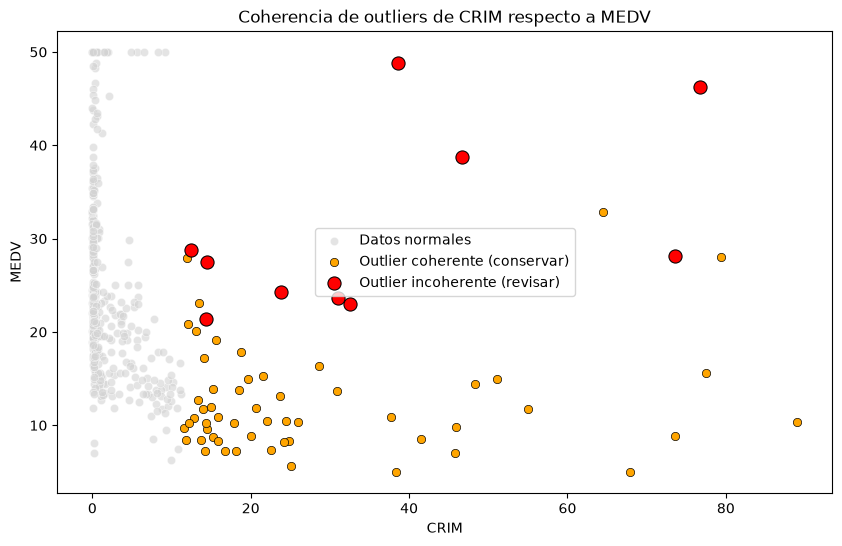

--- ZN ---
  límites IQR: [-30.00, 50.00]  -> 55 outliers totales
  incoherentes (rompen >=50% de lo evaluable): 6


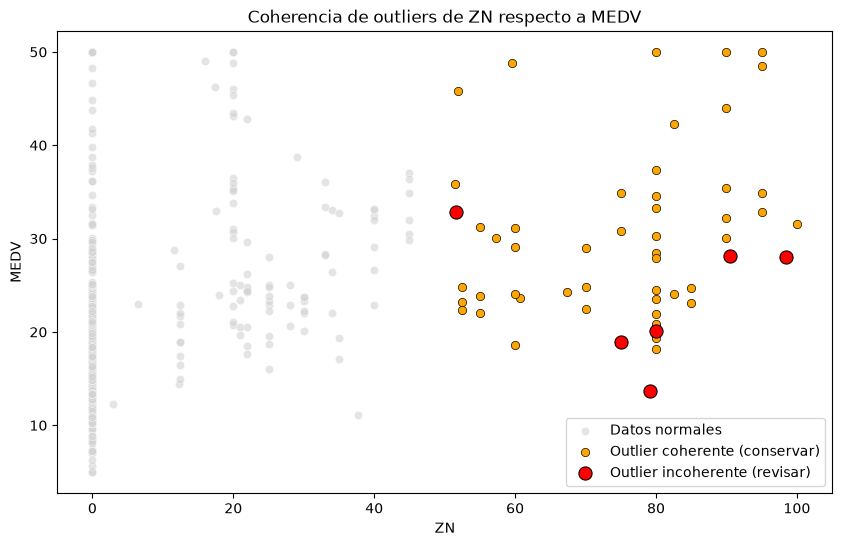

--- B ---
  límites IQR: [334.97, 432.68]  -> 87 outliers totales
  incoherentes (rompen >=50% de lo evaluable): 21


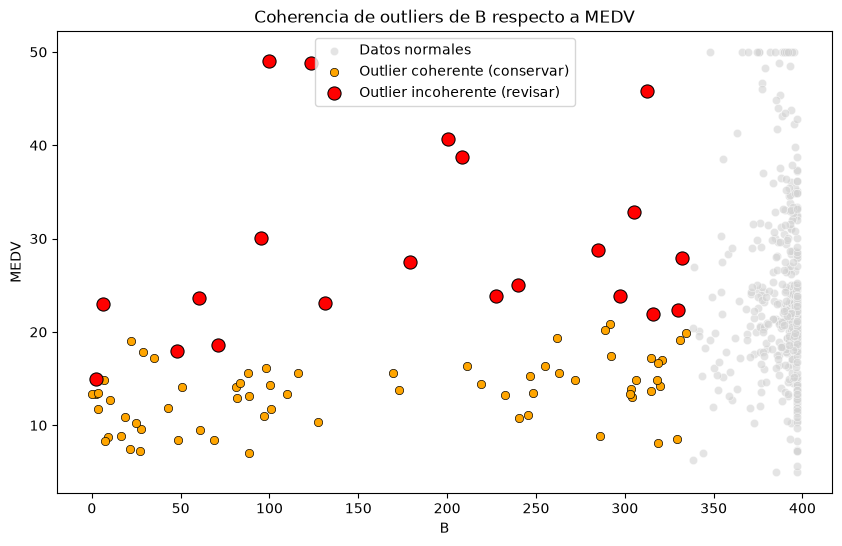

In [15]:
resultados = {}
for col, cfg in config.items():
    outliers, incoherentes = chequear_coherencia(df_limpio, col, **cfg, umbral_fraccion=0.5)
    resultados[col] = (outliers, incoherentes)
    graficar_coherencia(df_limpio, col, outliers, incoherentes)

## Triangulación entre variables

Una fila que rompe el patrón esperado en **más de una** variable independiente es un candidato mucho más fuerte a revisión que una fila que solo lo rompe en una. No es automático que se elimine: es el punto de partida para decidir con criterio (diagnóstico de influencia, regresión robusta, o exclusión justificada y comparando métricas con/sin esas filas).

In [16]:
indices = [set(incoh.index) for _, incoh in resultados.values()]
interseccion = set.union(*[
    indices[i] & indices[j]
    for i in range(len(indices)) for j in range(i + 1, len(indices))
])

print("--- Triangulación: filas incoherentes en MÁS DE UNA variable ---")
print(f"Filas candidatas a revisión prioritaria: {sorted(interseccion)}")

cols_mostrar = ['CRIM', 'ZN', 'B', 'RM', 'LSTAT', 'INDUS', 'MEDV']
df_limpio.loc[sorted(interseccion), cols_mostrar]

--- Triangulación: filas incoherentes en MÁS DE UNA variable ---
Filas candidatas a revisión prioritaria: [14, 23, 264, 298, 316, 458, 520, 554]


,CRIM,ZN,B,RM,LSTAT,INDUS,MEDV
14,30.986519,60.711549,60.162028,NaN,30.494822,8.827191,23.675363
23,73.605747,90.434661,NaN,8.050076,NaN,12.740286,28.130115
264,38.608079,59.561339,123.454526,3.839536,3.389871,15.551495,48.854539
298,14.438300,0.000000,179.360000,6.852000,19.780000,18.100000,27.500000
316,46.636848,29.085822,208.319346,4.590182,9.797431,23.676385,38.715522
458,12.510504,11.610423,284.787493,7.949105,27.789443,14.404205,28.812426
520,64.454622,51.572705,305.396257,5.656463,33.964324,12.832008,32.857900
554,32.504013,6.528591,6.267059,4.016588,7.033962,8.937346,23.028798


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer

# --- 1. Separar X e y, y hacer el split ANTES de tocar las filas "raras" ---
X = df_limpio.drop(columns='MEDV')
y = df_limpio['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 2. Eliminar las 8 filas SOLO si cayeron en train ---
# Nunca se eliminan filas del test: tiene que reflejar los datos reales,
# con sus casos difíciles incluidos, tal como el modelo los va a enfrentar
# en producción.
filas_a_eliminar = [14, 23, 264, 298, 316, 458, 520, 554]

filas_en_train = [i for i in filas_a_eliminar if i in X_train.index]
filas_en_test  = [i for i in filas_a_eliminar if i in X_test.index]

print(f"Se eliminan de train: {filas_en_train}")
print(f"Se CONSERVAN en test (aunque estén en la lista): {filas_en_test}")

X_train = X_train.drop(index=filas_en_train)
y_train = y_train.drop(index=filas_en_train)

Se eliminan de train: [14, 23, 264, 298, 316, 458, 554]
Se CONSERVAN en test (aunque estén en la lista): [520]


In [19]:
columnas_numericas = [c for c in X_train.columns if c not in ['CHAS', 'RAD']]

scaler = RobustScaler()  # usa mediana e IQR en vez de media/desvío,
                         # porque CRIM/ZN/B siguen teniendo outliers
                         # legítimos que decidiste CONSERVAR

# fit_transform: el escalador APRENDE la mediana y el IQR únicamente de
# train, y transforma train con esos valores.
X_train_esc = X_train.copy()
X_train_esc[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])

# transform (sin fit): a test se le aplican la mediana y el IQR que ya
# aprendió de train. Test nunca participa en el cálculo del escalador.
X_test_esc = X_test.copy()
X_test_esc[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

Filas completas en train usadas para el experimento: 406
 k  nrmse_medio  nrmse_std
 1     0.732739   0.092182
 2     0.669546   0.071073
 3     0.638884   0.065840
 5     0.623045   0.057406
 7     0.622195   0.060491
10     0.626590   0.055135
15     0.638206   0.054656
20     0.649525   0.059200
25     0.658247   0.059175
30     0.668113   0.059809


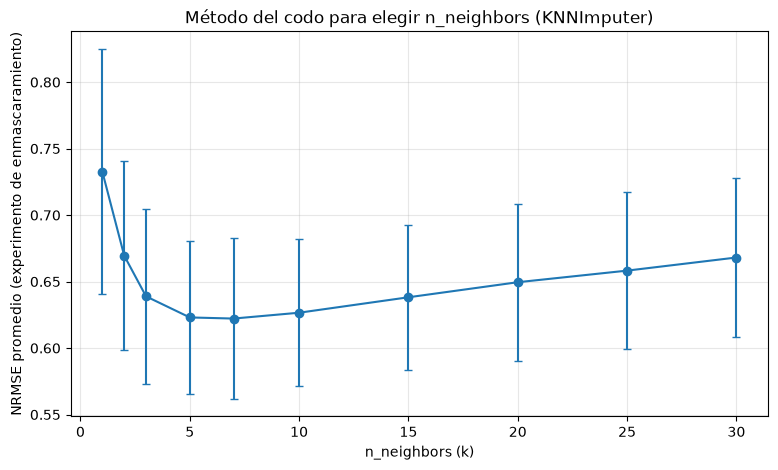


k con menor NRMSE promedio (mínimo exacto de la curva): 7
Mirá el gráfico: el 'codo' (donde la curva se aplana) suele quedar
un poco ANTES del mínimo exacto. Si varios k están dentro del mismo
desvío estándar entre sí, priorizá el más chico de esa zona plana
(más conservador con la varianza original de los datos).


In [20]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
 
 
def enmascarar_y_medir(datos_verdad, fraccion_mascara, k, rng):
    """
    Enmascara aleatoriamente una fracción de las celdas de 'datos_verdad',
    imputa con KNNImputer(n_neighbors=k) y devuelve el NRMSE de la
    reconstrucción, calculado solo sobre las celdas enmascaradas.
    """
    mascara = rng.random(datos_verdad.shape) < fraccion_mascara
    datos_enmascarados = datos_verdad.copy()
    datos_enmascarados[mascara] = np.nan
 
    imputer = KNNImputer(n_neighbors=k)
    reconstruido = imputer.fit_transform(datos_enmascarados)
 
    # Normalizamos por el desvío de cada columna para poder promediar
    # el error entre columnas de escalas distintas.
    std_cols = datos_verdad.std(axis=0)
    error = (reconstruido[mascara] - datos_verdad[mascara]) ** 2
    std_expandido = np.tile(std_cols, (datos_verdad.shape[0], 1))[mascara]
    return np.sqrt(np.mean(error / (std_expandido ** 2 + 1e-12)))
 
 
def curva_del_codo(datos_verdad, ks, n_repeticiones=15, fraccion_mascara=0.05):
    """
    Repite el experimento de enmascaramiento 'n_repeticiones' veces para
    cada valor de k, y devuelve una tabla con la media y el desvío del
    NRMSE por k.
 
    Parámetros
    ----------
    datos_verdad : array 2D con las filas completas de train (sin NaN)
    ks : lista de valores de n_neighbors a probar
    n_repeticiones : cuántas máscaras aleatorias distintas promediar
                      (más repeticiones = curva más estable, menos ruido)
    fraccion_mascara : proporción de celdas que se enmascaran en cada
                        repetición (0.05 = 5%, para tener suficientes
                        celdas enmascaradas y un resultado confiable)
    """
    filas = []
    for k in ks:
        errores = []
        for rep in range(n_repeticiones):
            rng = np.random.default_rng(rep)
            errores.append(enmascarar_y_medir(datos_verdad, fraccion_mascara, k, rng))
        filas.append({
            'k': k,
            'nrmse_medio': np.mean(errores),
            'nrmse_std': np.std(errores),
        })
    return pd.DataFrame(filas)
 
 
def graficar_codo(tabla_resultados):
    """Grafica NRMSE promedio (+/- desvío) vs k, para ubicar el codo a ojo."""
    plt.figure(figsize=(9, 5))
    plt.errorbar(
        tabla_resultados['k'], tabla_resultados['nrmse_medio'],
        yerr=tabla_resultados['nrmse_std'], marker='o', capsize=3
    )
    plt.title('Método del codo para elegir n_neighbors (KNNImputer)')
    plt.xlabel('n_neighbors (k)')
    plt.ylabel('NRMSE promedio (experimento de enmascaramiento)')
    plt.grid(alpha=0.3)
    plt.show()
 
 
if __name__ == '__main__':
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import RobustScaler
 
    # --- Reproduce los pasos previos del pipeline (split, outliers, escalado) ---
    df = pd.read_csv('house-prices-tp.csv')
    df_limpio = df.dropna(subset=['MEDV']).copy()
 
    filas_a_eliminar = [14, 23, 264, 298, 316, 458, 520, 554]
    X = df_limpio.drop(columns='MEDV')
    y = df_limpio['MEDV']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    filas_en_train = [i for i in filas_a_eliminar if i in X_train.index]
    X_train = X_train.drop(index=filas_en_train)
    y_train = y_train.drop(index=filas_en_train)
 
    columnas_continuas = [c for c in X_train.columns if c not in ['CHAS', 'RAD']]
    scaler = RobustScaler()
    X_train_esc = X_train.copy()
    X_train_esc[columnas_continuas] = scaler.fit_transform(X_train[columnas_continuas])
 
    # --- Método del codo: SOLO con las filas completas de TRAIN ---
    # (nunca se usa test para elegir el hiperparámetro k)
    completas = X_train_esc[columnas_continuas].dropna().copy()
    print(f"Filas completas en train usadas para el experimento: {completas.shape[0]}")
 
    datos_verdad = completas.to_numpy()
    ks_a_probar = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30]
 
    tabla = curva_del_codo(datos_verdad, ks_a_probar, n_repeticiones=15, fraccion_mascara=0.05)
    print(tabla.to_string(index=False))
 
    graficar_codo(tabla)
 
    k_minimo = int(tabla.loc[tabla['nrmse_medio'].idxmin(), 'k'])
    print(f"\nk con menor NRMSE promedio (mínimo exacto de la curva): {k_minimo}")
    print("Mirá el gráfico: el 'codo' (donde la curva se aplana) suele quedar")
    print("un poco ANTES del mínimo exacto. Si varios k están dentro del mismo")
    print("desvío estándar entre sí, priorizá el más chico de esa zona plana")
    print("(más conservador con la varianza original de los datos).")

In [21]:
# --- 4. Imputar con KNNImputer, ya sobre los datos escalados ---
imputer = KNNImputer(n_neighbors=5)  

# fit_transform: el "banco de vecinos" de KNN se construye SOLO con las
# filas de train.
X_train_imp = X_train_esc.copy()
X_train_imp[columnas_continuas] = imputer.fit_transform(X_train_esc[columnas_continuas])

# transform (sin fit): para imputar cada fila de test, KNN busca sus
# vecinos más cercanos DENTRO del banco de train (nunca mira otras filas
# de test entre sí).
X_test_imp = X_test_esc.copy()
X_test_imp[columnas_continuas] = imputer.transform(X_test_esc[columnas_continuas])